In [1]:
import os

import umap 
from pathlib import Path
import networkx as nx
import nx_cugraph as nxcg
from networkx.linalg.algebraicconnectivity import algebraic_connectivity
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader as DataLoader
import pandas as pd
import numpy as np 

from graphvae.model import GraphVAE
from graphvae.data import GraphAdjSampler

/net/dali/home/uttam/zic87/micromamba/envs/graph-generation/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Build a VAE model
def build_model(feature_type, max_num_nodes):
    out_dim = max_num_nodes * (max_num_nodes + 1) // 2
    if feature_type == 'id':
        input_dim = max_num_nodes
    elif feature_type == 'deg':
        input_dim = 1
    elif feature_type == 'struct':
        input_dim = 2
    model = GraphVAE(input_dim, 64, 256, max_num_nodes)
    return model

def extract_vae_latent(model, input_features, adj):
    B, N, _ = adj.shape
    x = model.conv1(input_features, adj)
    x = model.bn1(x.transpose(1, 2)).transpose(1, 2)
    x = model.act(x)
    x = model.conv2(x, adj)
    x = model.bn2(x.transpose(1, 2)).transpose(1, 2)

    # pool over all nodes 
    graph_h = model.pool_graph(x)

    # vae
    h_decode, z_mu, z_lsgms = model.vae(graph_h)
    return h_decode, z_mu, z_lsgms

# Extract latent vectors
def extract_latents(model, dataloader, device='cpu'):
    latents = []
    with torch.no_grad():
        for batch_idx, data in enumerate(dataloader):
            model.zero_grad()
            features = data['features'].float()
            adj_input = data['adj'].float()

            features = torch.tensor(features).to(device)
            adj_input = torch.tensor(adj_input).to(device)
            
            h_decode, z_mu, z_lsgms = extract_vae_latent(model, features, adj_input)
            latents.append(z_mu.cpu())
    return torch.cat(latents, dim=0)

In [3]:
run = '51'
batch_size = 10
num_workers = 1
feature_type = 'id'
max_node = 10
model_name = 'node-1_lr0.0001_epoch52_mixed_id_2025-04-18_00-12-17'

vae_folder = Path('graphvae')
model_path = vae_folder / Path('model_save') / model_name / Path('graphvae_{0}.dat'.format(run))
graph_dir = Path('graphs/mixed/') 

output_dir = Path('results')
output_dir.mkdir(parents=True, exist_ok=True)
figure_dir = output_dir / Path('figures')
figure_dir.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'device: {device}')

device: cuda


In [4]:
# %%timeit

graphs = {}

for file_path in list(graph_dir.glob('*.txt')):
    graph_name = file_path.parts[-1]
    graph = nx.read_edgelist(file_path)
    graphs[graph_name] = graph
    
print(len(graphs.keys()))

120


In [5]:
graph_list = [v for k, v in graphs.items()]
graph_name_list = [k.split('.txt')[0] for k, v in graphs.items()]
trans_list = [nx.transitivity(v) for k, v in graphs.items()]
num_node_list = [k.split('_')[1] for k in graphs.keys()]
family_list = [k.split('_')[0] for k in graphs.keys()]
edge_num_list = [v.number_of_edges() for k, v in graphs.items()]

In [6]:
conn_list = [nx.algebraic_connectivity(v) for k, v in graphs.items()]

In [7]:
def get_degree_var(G):
    degrees = [d for n, d in G.degree()]
    degree_var = np.var(degrees)
    return degree_var

def get_degree_mean(G):
    degrees = [d for n, d in G.degree()]
    degree_mean = np.mean(degrees)
    return degree_mean

In [8]:
graph_degrees_var = [get_degree_var(v) for k, v in graphs.items()]
graph_degrees_mean = [get_degree_mean(v) for k, v in graphs.items()]

In [9]:
# Load model
model = build_model('id', max_node).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

/net/dali/home/uttam/zic87/TreeNet/graphvae/model.py:39: FutureWarning: `nn.init.xavier_uniform` is now deprecated in favor of `nn.init.xavier_uniform_`.
  m.weight.data = init.xavier_uniform(m.weight.data, gain=nn.init.calculate_gain('relu'))
/net/dali/home/uttam/zic87/TreeNet/graphvae/model.py:81: FutureWarning: `nn.init.xavier_uniform` is now deprecated in favor of `nn.init.xavier_uniform_`.
  m.weight.data = init.xavier_uniform(m.weight.data, gain=nn.init.calculate_gain('relu'))


GraphVAE(
  (conv1): GraphConv()
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): GraphConv()
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act): ReLU()
  (vae): MLP_VAE_plain(
    (encode_11): Linear(in_features=64, out_features=256, bias=True)
    (encode_12): Linear(in_features=64, out_features=256, bias=True)
    (decode_1): Linear(in_features=256, out_features=256, bias=True)
    (decode_2): Linear(in_features=256, out_features=55, bias=True)
    (relu): ReLU()
  )
)

In [10]:
dataset = GraphAdjSampler(graph_list, max_node, features=feature_type)

In [11]:
dataset_loader = torch.utils.data.DataLoader(
            dataset, 
            batch_size=batch_size, 
            num_workers=num_workers)

In [12]:
latent_representations = extract_latents(model, dataset_loader, device)
print(latent_representations.shape)

/tmp/ipykernel_4183029/104452328.py:37: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  features = torch.tensor(features).to(device)
/tmp/ipykernel_4183029/104452328.py:38: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  adj_input = torch.tensor(adj_input).to(device)


torch.Size([120, 256])


/net/dali/home/uttam/zic87/TreeNet/graphvae/model.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  eps = torch.tensor(torch.randn(z_sgm.size())).to(DEVICE)


In [13]:
filtered_idx = [i for i in range(len(family_list))]
# filtered_idx = [i for i in range(len(family_list)) if (family_list[i] == 'BA') or (family_list[i] == 'Regular') ]


In [14]:
# Plot UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
embedding = reducer.fit_transform(latent_representations[filtered_idx])  # shape (30, 2)

/net/dali/home/uttam/zic87/micromamba/envs/graph-generation/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/net/dali/home/uttam/zic87/micromamba/envs/graph-generation/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


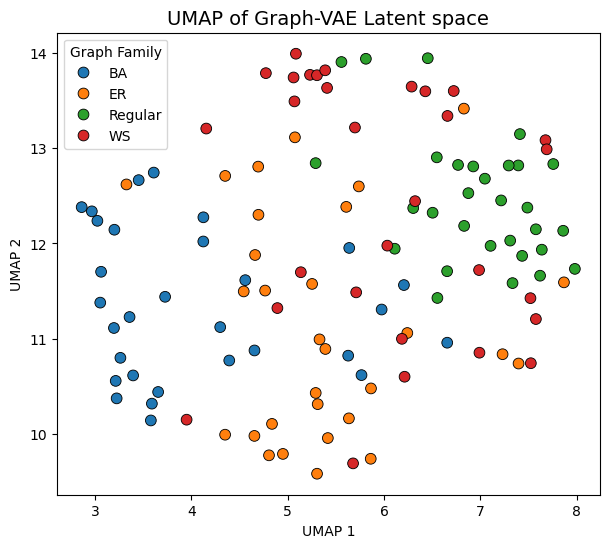

In [15]:
# Plotting
plt.figure(figsize=(7, 6))
scatter = sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], 
            hue=[family_list[i] for i in filtered_idx], s=60, edgecolor='k')
plt.legend(title='Graph Family')
plt.title("UMAP of Graph-VAE Latent space", fontsize=14)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
output_fig_path = figure_dir / Path('umap_graph_type.png')
plt.savefig(output_fig_path, bbox_inches='tight')

In [17]:
graph_data = pd.DataFrame({
    'graph_name':graph_name_list,
    'transitivity': trans_list,
    'connectivity': conn_list,
    'embed_x': embedding[:, 0],
    'embed_y': embedding[:, 1],
    'degree_var': graph_degrees_var,
    'degree_mean': graph_degrees_mean
})

#### Examine Tree structures

In [18]:
output_fpath = output_dir / Path("processed/coalescence_sackin_mixed.pkl")

In [19]:
df = pd.read_pickle(output_fpath)
df_joint = df.merge(graph_data, on='graph_name')
df_joint = df_joint.sort_values(['graph_type', 'rep']).reset_index(drop=True)

In [20]:
coal_max = df_joint['Js'].max()
max_idx = df_joint[df_joint['Js']==coal_max].index
df_joint = df_joint.drop(max_idx)

In [36]:
colormap = {
    'BA':sns.color_palette("tab10")[2], 
    'ER':sns.color_palette("tab10")[0],
    'Regular':sns.color_palette("tab10")[3], 
    'WS':sns.color_palette("tab10")[1]
}

marker_dict = {
    'ER': 'o',
    'WS': 'v',
    'BA': 's', 
    'Regular': '*'
}

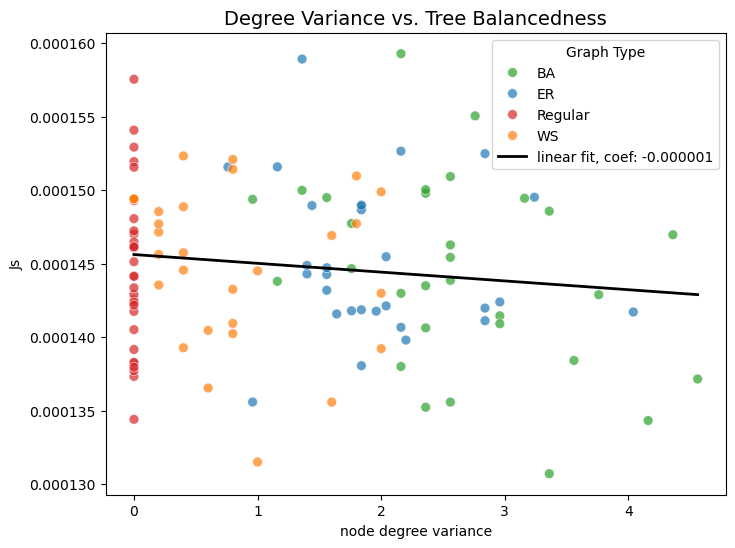

In [62]:
# Plotting
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_joint['degree_var'], y=df_joint['Js'], hue=df_joint['graph_type'], s=50, alpha=0.7, palette=colormap)

# for gt in df_joint['graph_type'].unique():
#     # if gt == 'ER':
#     #     continue
#     subset = df_joint[df_joint['graph_type']==gt]
#     scatter = plt.scatter(subset['degree_var'], subset['Js'], label=gt)
    
try:
    poly_degree = 1
    x_data = df_joint['degree_var']
    y_data = df_joint['Js']
    coeffs = np.polyfit(x_data, y_data, poly_degree)
    poly = np.poly1d(coeffs)
    x_range = np.linspace(x_data.min(), x_data.max(), 200)
    plt.plot(x_range, poly(x_range), color='black', linestyle='-', linewidth=2, label=f'linear fit, coef: {coeffs[0]:.06f}')
    
except np.linalg.LinAlgError:
    print(f"Skipped global fit for {y} vs {x} due to numerical issues.")
    
plt.title("Degree Variance vs. Tree Balancedness", fontsize=14)
plt.legend(title="Graph Type")  # Adds a legend
plt.xlabel("node degree variance")
plt.ylabel("Js")
output_fig_path = figure_dir / Path('scatter_degree_var_J.png')
plt.savefig(output_fig_path, bbox_inches='tight')

In [50]:
df_joint.columns

Index(['graph_type', 'graph_name', 'rep', 'mean_coalescence_time',
       'variance_coalescence_time', 'sackin', 'sackin_variance', 'Js',
       'variance_Js', 'transitivity', 'connectivity', 'embed_x', 'embed_y',
       'degree_var', 'degree_mean'],
      dtype='object')

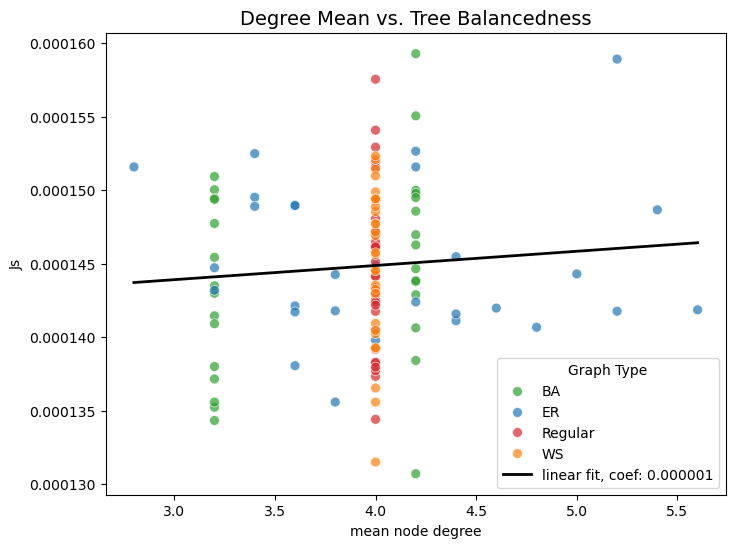

In [60]:
# Plotting
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_joint['degree_mean'], y=df_joint['Js'], hue=df_joint['graph_type'], s=50, alpha=0.7, palette=colormap)

# for gt in df_joint['graph_type'].unique():
#     # if gt == 'ER':
#     #     continue
#     subset = df_joint[df_joint['graph_type']==gt]
#     scatter = plt.scatter(subset['degree_var'], subset['Js'], label=gt)
    
try:
    poly_degree = 1
    x_data = df_joint['degree_mean']
    y_data = df_joint['Js']
    coeffs = np.polyfit(x_data, y_data, poly_degree)
    poly = np.poly1d(coeffs)
    x_range = np.linspace(x_data.min(), x_data.max(), 200)
    plt.plot(x_range, poly(x_range), color='black', linestyle='-', linewidth=2, label=f'linear fit, coef: {coeffs[0]:.06f}')
    
except np.linalg.LinAlgError:
    print(f"Skipped global fit for {y} vs {x} due to numerical issues.")
    
plt.title("Degree Mean vs. Tree Balancedness", fontsize=14)
plt.legend(title="Graph Type")  # Adds a legend
plt.xlabel("mean node degree")
plt.ylabel("Js")
output_fig_path = figure_dir / Path('scatter_degree_mean_J.png')
plt.savefig(output_fig_path, bbox_inches='tight')

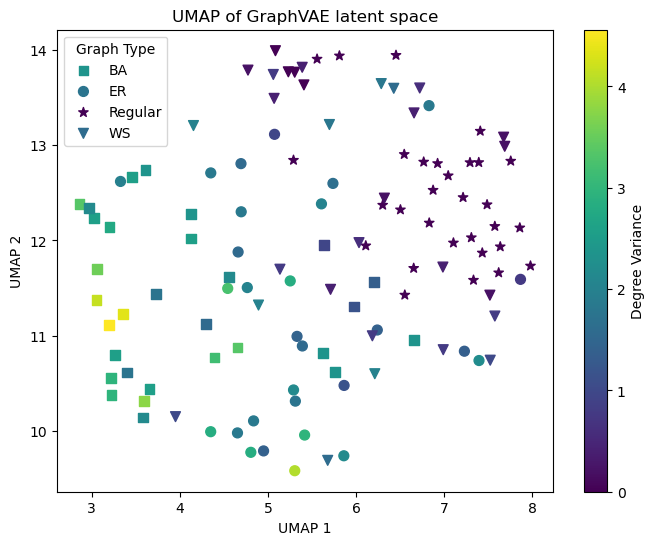

In [24]:
# Plotting
vmin = df_joint['degree_var'].min()
vmax = df_joint['degree_var'].max()

plt.figure(figsize=(8, 6))
for gt in df_joint['graph_type'].unique():
    # if gt == 'ER':
    #     continue
    subset = df_joint[df_joint['graph_type']==gt]
    scatter = plt.scatter(subset['embed_x'], subset['embed_y'], 
                          marker=marker_dict[gt], c=subset['degree_var'], 
                          s=50, label=gt, vmin=vmin, vmax=vmax)

plt.colorbar(scatter, label='Degree Variance')
plt.title("UMAP of GraphVAE latent space", fontsize=12)
plt.legend(title="Graph Type")  # Adds a legend
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
output_fig_path = figure_dir / Path('umap_degree_var.png')
plt.savefig(output_fig_path, bbox_inches='tight')

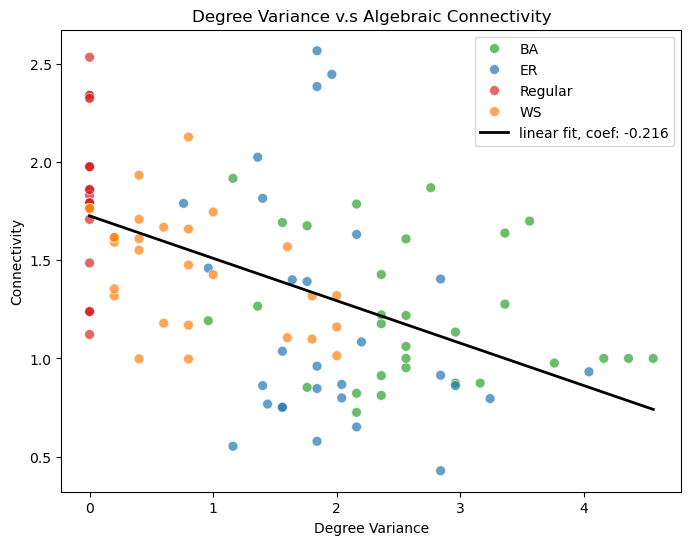

In [25]:
colormap = {
    'BA':sns.color_palette("tab10")[2], 
    'ER':sns.color_palette("tab10")[0],
    'Regular':sns.color_palette("tab10")[3], 
    'WS':sns.color_palette("tab10")[1]
}

plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_joint['degree_var'], y=df_joint['connectivity'], hue=df_joint['graph_type'], s=50, alpha=0.7, palette=colormap)
try:
    poly_degree = 1
    x_data = df_joint['degree_var']
    y_data = df_joint['connectivity']
    coeffs = np.polyfit(x_data, y_data, poly_degree)
    poly = np.poly1d(coeffs)
    x_range = np.linspace(x_data.min(), x_data.max(), 200)
    plt.plot(x_range, poly(x_range), color='black', linestyle='-', linewidth=2, label=f'linear fit, coef: {coeffs[0]:.03f}')
    
except np.linalg.LinAlgError:
    print(f"Skipped global fit for {y} vs {x} due to numerical issues.")
    
plt.title("Degree Variance v.s Algebraic Connectivity", fontsize=12)
plt.legend()  # Adds a legend
plt.xlabel("Degree Variance")
plt.ylabel("Connectivity")
output_fig_path = figure_dir / Path('reg_conn_degree_var.png')
plt.savefig(output_fig_path, bbox_inches='tight')
    

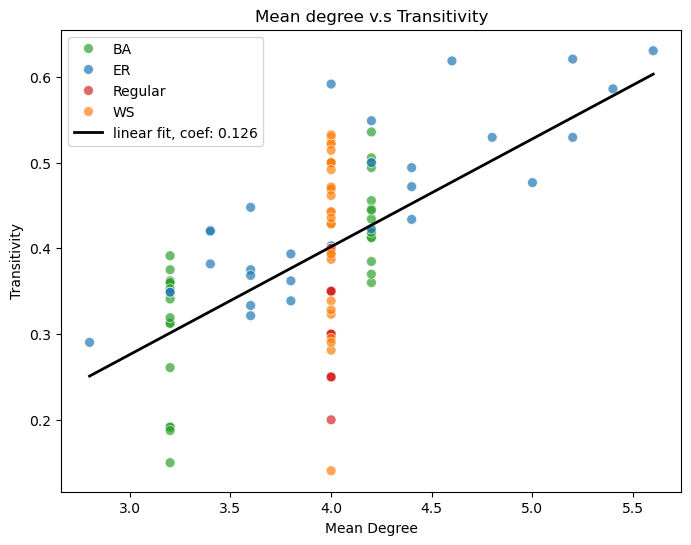

In [26]:
colormap = {
    'BA':sns.color_palette("tab10")[2], 
    'ER':sns.color_palette("tab10")[0],
    'Regular':sns.color_palette("tab10")[3], 
    'WS':sns.color_palette("tab10")[1]
}

plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_joint['degree_mean'], y=df_joint['transitivity'], hue=df_joint['graph_type'], s=50, alpha=0.7, palette=colormap)
try:
    poly_degree = 1
    x_data = df_joint['degree_mean']
    y_data = df_joint['transitivity']
    coeffs = np.polyfit(x_data, y_data, poly_degree)
    poly = np.poly1d(coeffs)
    x_range = np.linspace(x_data.min(), x_data.max(), 200)
    plt.plot(x_range, poly(x_range), color='black', linestyle='-', linewidth=2, label=f'linear fit, coef: {coeffs[0]:.03f}')
    
except np.linalg.LinAlgError:
    print(f"Skipped global fit for {y} vs {x} due to numerical issues.")
    
plt.title("Mean degree v.s Transitivity", fontsize=12)
plt.legend()  # Adds a legend
plt.xlabel("Mean Degree")
plt.ylabel("Transitivity")
output_fig_path = figure_dir / Path('reg_mean_degree_transitivity.png')
plt.savefig(output_fig_path, bbox_inches='tight')
    

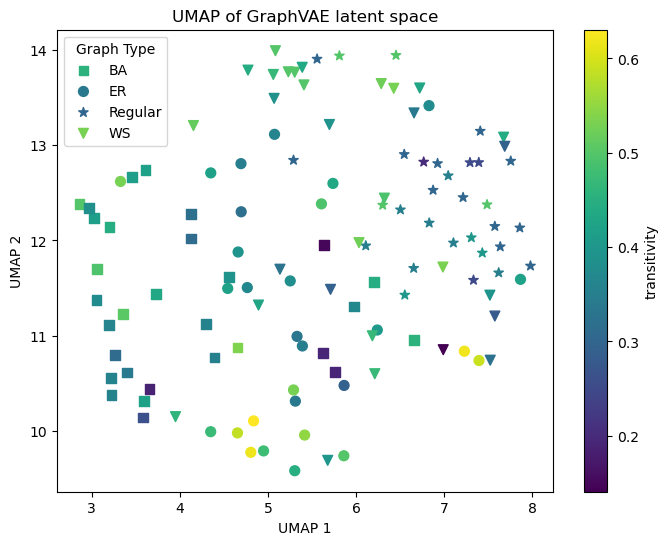

In [27]:
# Plotting
color_feat = 'transitivity'
vmin = df_joint[color_feat].min()
vmax = df_joint[color_feat].max()

plt.figure(figsize=(8, 6))
for gt in df_joint['graph_type'].unique():
    # if gt == 'ER':
    #     continue
    subset = df_joint[df_joint['graph_type']==gt]
    scatter = plt.scatter(subset['embed_x'], subset['embed_y'], 
                          marker=marker_dict[gt], c=subset[color_feat], 
                          s=50, label=gt, vmin=vmin, vmax=vmax)

plt.colorbar(scatter, label=color_feat)
plt.title("UMAP of GraphVAE latent space", fontsize=12)
plt.legend(title="Graph Type")  # Adds a legend
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
output_fig_path = figure_dir / Path(f'umap_{color_feat}.png')
plt.savefig(output_fig_path, bbox_inches='tight')

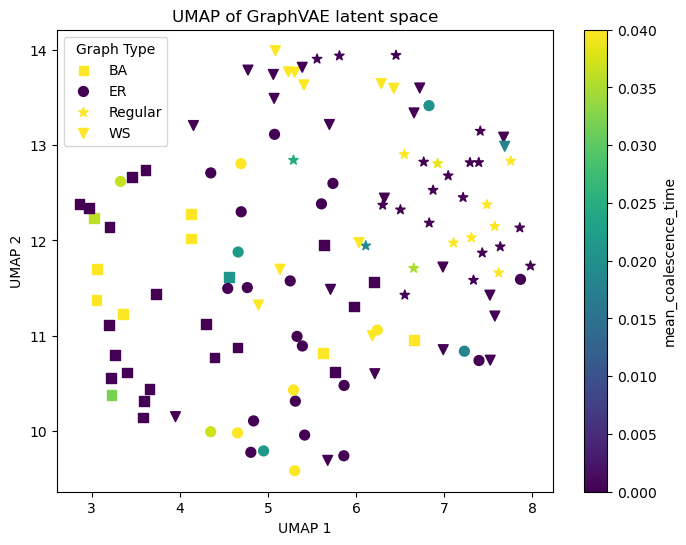

In [28]:
# Plotting
color_feat = 'mean_coalescence_time'
vmin = df_joint[color_feat].min()
vmax = 0.04

plt.figure(figsize=(8, 6))
for gt in df_joint['graph_type'].unique():
    # if gt == 'ER':
    #     continue
    subset = df_joint[df_joint['graph_type']==gt]
    scatter = plt.scatter(subset['embed_x'], subset['embed_y'], 
                          marker=marker_dict[gt], c=subset[color_feat], 
                          s=50, label=gt, vmin=vmin, vmax=vmax)

plt.colorbar(scatter, label=color_feat)
plt.title("UMAP of GraphVAE latent space", fontsize=12)
plt.legend(title="Graph Type")  # Adds a legend
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
output_fig_path = figure_dir / Path(f'umap_{color_feat}.png')
plt.savefig(output_fig_path, bbox_inches='tight')

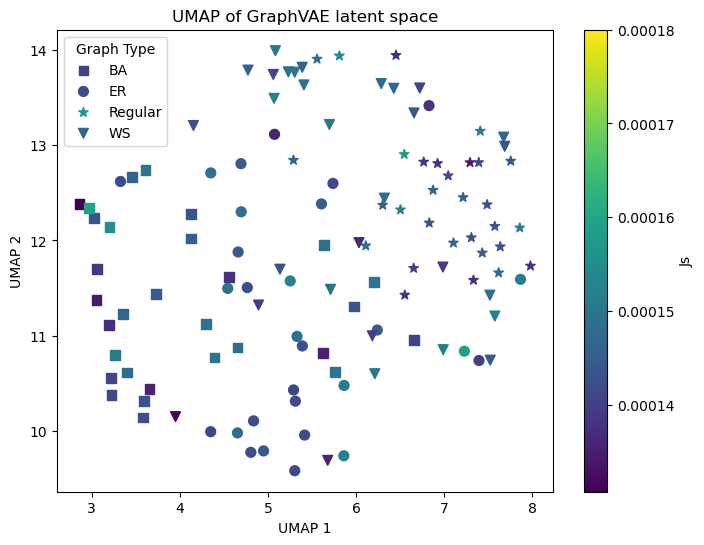

In [29]:
# Plotting
color_feat = 'Js'
vmin = df_joint[color_feat].min()
vmax = 0.00018

plt.figure(figsize=(8, 6))
for gt in df_joint['graph_type'].unique():
    # if gt == 'ER':
    #     continue
    subset = df_joint[df_joint['graph_type']==gt]
    scatter = plt.scatter(subset['embed_x'], subset['embed_y'], 
                          marker=marker_dict[gt], c=subset[color_feat], 
                          s=50, label=gt, vmin=vmin, vmax=vmax)

plt.colorbar(scatter, label=color_feat)
plt.title("UMAP of GraphVAE latent space", fontsize=12)
plt.legend(title="Graph Type")  # Adds a legend
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
output_fig_path = figure_dir / Path(f'umap_{color_feat}.png')
plt.savefig(output_fig_path, bbox_inches='tight')

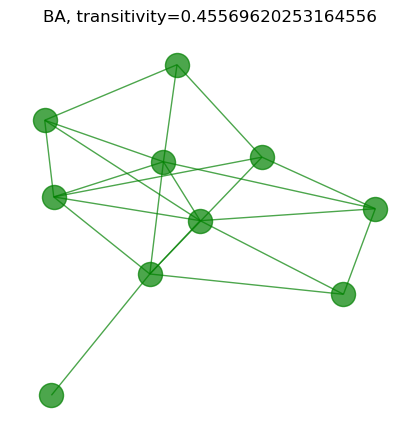

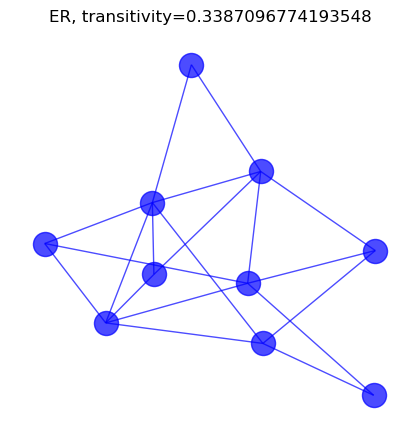

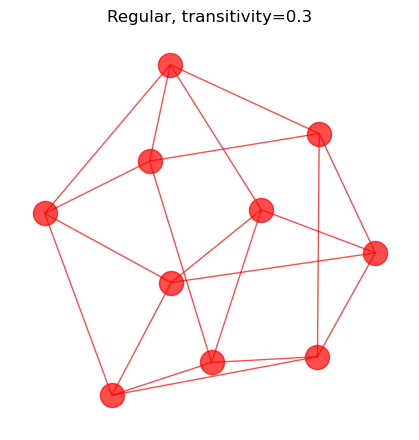

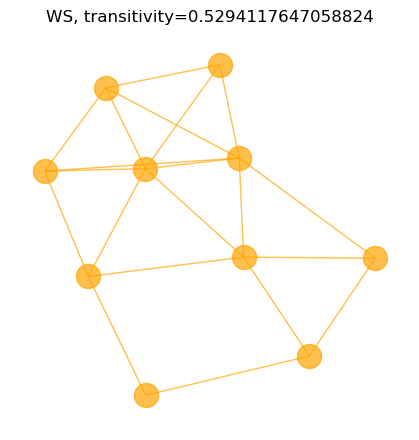

In [30]:
colormap = {'BA':'green', 'ER':'blue', 'Regular':'red', 'WS':'orange'}
# Plot networks
graph_idx = [0, 30, 60, 90]
for idx in graph_idx:
    plt.figure(figsize=(4, 4))
    nx.draw(graph_list[idx], node_color=colormap[family_list[idx]], edge_color=colormap[family_list[idx]], alpha=0.7)
    plt.title(f'{family_list[idx]}, transitivity={trans_list[idx]}')
    plt.show()

In [31]:
import toytree
tree_folder = Path("results/trees/mixed")
tree_list = list(tree_folder.glob("*_tree.txt"))
idx = 0


In [32]:
def build_toytree(file_path, index):
    """
    Builds a tree from a parent pointer list in a specified line of a file.
    """
    with open(file_path, 'r') as file:
        parent_data = file.readlines()[index].strip().split()

    node_dict = {}

    for idx, parent_id in enumerate(parent_data, start=1):
        if idx not in node_dict:
            node_dict[idx] = toytree.Node(name=str(idx))
        if int(parent_id) not in node_dict:
            node_dict[int(parent_id)] = toytree.Node(name=str(parent_id))

        toytree.mod.add_child_node(node_dict[0], int(parent_id),idx)
    
    return node_dict

In [33]:
tree_dict = build_toytree(tree_list[0], 0)
tree = tree_dict[0]


AttributeError: 'Node' object has no attribute 'get_mrca_node'

In [ ]:
import random

# Set the number of tips you want to keep
n_keep = 1  # adjust this number

# Get all leaf names
all_leaves = tree.get_leaf_names()

# Randomly select a subset
selected_leaves = set(random.sample(all_leaves, n_keep))
tree.prune(selected_leaves, preserve_branch_length=True)
all_leaves = tree.get_leaf_names()


In [ ]:
all_leaves

In [ ]:
tree